# Circuits for Lesson 5 of the Tutorial (Part 1)

The 23 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 5 of the Tutorial (Part 1)*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## 1. Bo2's Drill Exercise 3.2

In this problem, we use an ideal op amp (the o element) for the first time. Find vo and the power absorbed by the op amp. The op amp's power is negative, so it delivers 0.63 mW to the circuit rather than absorbing it.

![The circuit of Bo2's Drill Exercise 3.2](https://learn.symbulator.com/assets/circuit/bo2de0302.jpg)

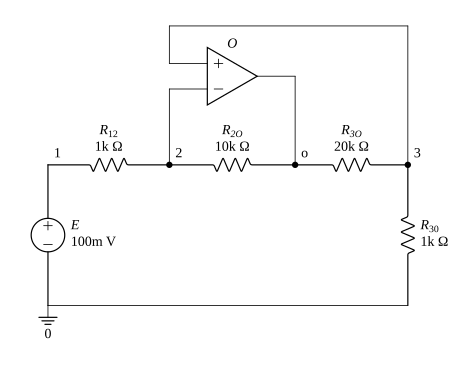

In [3]:
c1 = '''
e,1,0,.1
r12,1,2,1'k
r2o,2,o,10'k
r30,3,0,1'k
r3o,3,o,20'k
o,3,2,o
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1.rounded(2)

Result(domain='dc')
  i_e = -0.00020
  i_o = -0.00030
  i_r12 = 0.00020
  i_r2o = 0.00020
  i_r30 = -0.00010
  i_r3o = 0.00010
  p_e = -0.000020
  p_o = -0.00063
  p_r12 = 0.000040
  p_r2o = 0.00040
  p_r30 = 0.000010
  p_r3o = 0.00020
  r_e = 5.0E+2
  v_1 = 0.10
  v_2 = -0.10
  v_3 = -0.10
  v_e = 0.10
  v_o = -2.1
  v_r12 = 0.20
  v_r2o = 2.0
  v_r30 = -0.10
  v_r3o = 2.0

## 2. Bo2's Drill Exercise 3.11 (Thevenin)

Find the Thévenin equivalent of the op-amp circuit. The tricky one. An ideal op amp holds its output voltage whatever current is drawn, so the short-circuit round has no solution -- and until 0.5.13 the whole answer was lost with it. Symbulator now measures the short instead of assuming it, and reports what the chapter asserts but never shows: the Norton current is unbounded and the Thevenin resistance is 0.

![The circuit of Bo2's Drill Exercise 3.11 (Thevenin)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-3-11-thevenin-1.jpg)

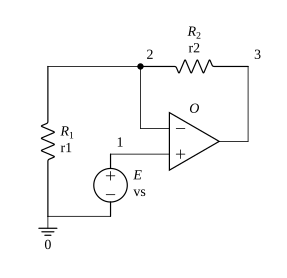

In [5]:
c2 = '''
e,1,0,vs
r1,2,0,r1
r2,2,3,r2
o,1,2,3
'''
draw(c2)

In [6]:
r2 = th(c2, '3', '0', domain='dc')
r2

TheveninResult(domain='dc', vth=vs*(r1 + r2)/r1, ino=oo, req=0, pmax=oo)

## 3. AS2's Example 5.2

Find vo and io: 9 V and 0.65 mA.

![The circuit of AS2's Example 5.2](https://learn.symbulator.com/assets/practice/as2s-example-5-2-3.jpg)

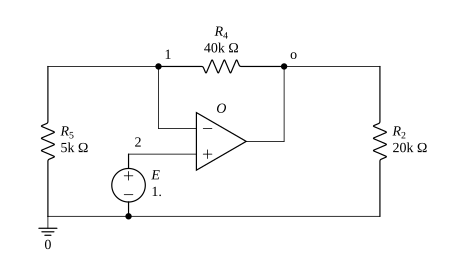

In [7]:
c3 = '''
e,2,0,1.
r5,1,0,5'k
r4,1,o,40'k
r2,o,0,20'k
o,2,1,o
'''
draw(c3)

In [8]:
r3 = dc(c3)
r3.rounded(2)

Result(domain='dc')
  i_e = 0
  i_o = 0.00065
  i_r2 = 0.00045
  i_r4 = -0.00020
  i_r5 = 0.00020
  p_e = 0
  p_o = -0.0059
  p_r2 = 0.0041
  p_r4 = 0.0016
  p_r5 = 0.00020
  r_e = oo
  v_1 = 1.0
  v_2 = 1.0
  v_e = 1.0
  v_o = 9.0
  v_r2 = 9.0
  v_r4 = -8.0
  v_r5 = 1.0

## 4. Bo2's Figure 3.3 (Inverting)

The inverting amplifier: find the overall gain, vo/vs, on the Evaluate line. It comes back -r2/r1.

![The circuit of Bo2's Figure 3.3 (Inverting)](https://learn.symbulator.com/assets/practice/bo2s-figure-3-3-inverting-4.jpg)

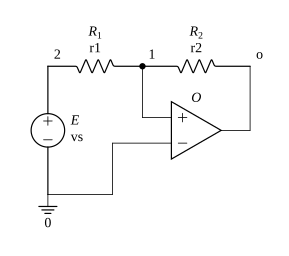

In [9]:
c4 = '''
e,2,0,vs
r1,2,1,r1
r2,1,o,r2
o,1,0,o
'''
draw(c4)

In [10]:
r4 = dc(c4)
r4

Result(domain='dc')
  i_e = -vs/r1
  i_o = -vs/r1
  i_r1 = vs/r1
  i_r2 = vs/r1
  p_e = -vs**2/r1
  p_o = -r2*vs**2/r1**2
  p_r1 = vs**2/r1
  p_r2 = r2*vs**2/r1**2
  r_e = r1
  v_1 = 0
  v_2 = vs
  v_e = vs
  v_o = -r2*vs/r1
  v_r1 = vs
  v_r2 = r2*vs/r1

In [11]:
evaluate(r4, 'vo/vs')

-r2/r1

## 5. AS2's Figure 5.10 (Inverting)

Find vo, symbolically: -(rf/r1)*vi.

![The circuit of AS2's Figure 5.10 (Inverting)](https://learn.symbulator.com/assets/practice/as2s-figure-5-10-inverting-5.jpg)

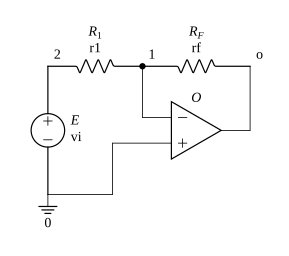

In [12]:
c5 = '''
e,2,0,vi
r1,2,1,r1
rf,1,o,rf
o,0,1,o
'''
draw(c5)

In [13]:
r5 = dc(c5)
r5

Result(domain='dc')
  i_e = -vi/r1
  i_o = -vi/r1
  i_r1 = vi/r1
  i_rf = vi/r1
  p_e = -vi**2/r1
  p_o = -rf*vi**2/r1**2
  p_r1 = vi**2/r1
  p_rf = rf*vi**2/r1**2
  r_e = r1
  v_1 = 0
  v_2 = vi
  v_e = vi
  v_o = -rf*vi/r1
  v_r1 = vi
  v_rf = rf*vi/r1

## 6. AS2's Example 5.3 (Inverting)

With vi = 0.5 V, find the output voltage vo and the current in the 10 kohm resistor.

![The circuit of AS2's Example 5.3 (Inverting)](https://learn.symbulator.com/assets/practice/as2s-example-5-3-inverting-6.jpg)

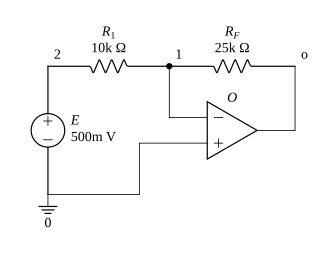

In [14]:
c6 = '''
e,2,0,.5
r1,2,1,10'k
rf,1,o,25'k
o,0,1,o
'''
draw(c6)

In [15]:
r6 = dc(c6)
r6.rounded(3)

Result(domain='dc')
  i_e = -0.0000500
  i_o = -0.0000500
  i_r1 = 0.0000500
  i_rf = 0.0000500
  p_e = -0.0000250
  p_o = -0.0000625
  p_r1 = 0.0000250
  p_rf = 0.0000625
  r_e = 1.00E+4
  v_1 = 0
  v_2 = 0.500
  v_e = 0.500
  v_o = -1.25
  v_r1 = 0.500
  v_rf = 1.25

## 7. TR5's Exercise 4-11 (Inverting)

Find vo when vs is 2 V, -4 V and 6 V. The Evaluate line answers vs = 2: -6.6 V. For the other two, put vs = -4 then vs = 6 in Evaluate's Conditions box: 13.2 and -19.8. The op amp is limited to +/-15 V, so the real answer for vs = 6 is -15.

![The circuit of TR5's Exercise 4-11 (Inverting)](https://learn.symbulator.com/assets/practice/tr5s-exercise-4-11-inverting-7.jpg)

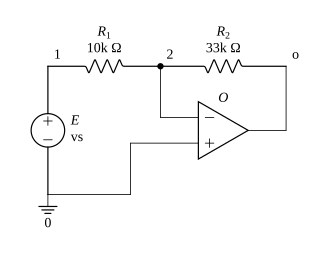

In [16]:
c7 = '''
e,1,0,vs
r1,1,2,10'k
r2,2,o,33'k
o,0,2,o
'''
draw(c7)

In [17]:
r7 = dc(c7)
r7.rounded(3)

Result(domain='dc')
  i_e = -0.0001*vs
  i_o = -0.0001*vs
  i_r1 = 0.0001*vs
  i_r2 = 0.0001*vs
  p_e = -0.0001*vs**2
  p_o = -0.00033*vs**2
  p_r1 = 0.0001*vs**2
  p_r2 = 0.00033*vs**2
  r_e = 10000
  v_1 = vs
  v_2 = 0
  v_e = vs
  v_o = -3.3*vs
  v_r1 = vs
  v_r2 = 3.3*vs

In [18]:
evaluate(r7, 'vo', conditions=['vs = 2'])

-33/5

## 8. AS2's Practice Problem 5.3 (Inverting)

Find the op amp's output voltage vo and the current through the 15 kohm feedback resistor.

![The circuit of AS2's Practice Problem 5.3 (Inverting)](https://learn.symbulator.com/assets/practice/as2s-practice-problem-5-3-inverting-8.jpg)

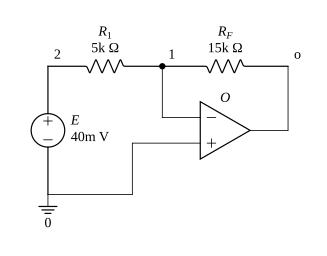

In [19]:
c8 = '''
e,2,0,40'm
r1,2,1,5'k
rf,1,o,15'k
o,0,1,o
'''
draw(c8)

In [20]:
r8 = dc(c8)
r8.rounded(3)

Result(domain='dc')
  i_e = -0.00000800
  i_o = -0.00000800
  i_r1 = 0.00000800
  i_rf = 0.00000800
  p_e = -3.20E-7
  p_o = -9.60E-7
  p_r1 = 3.20E-7
  p_rf = 9.60E-7
  r_e = 5000
  v_1 = 0
  v_2 = 0.0400
  v_e = 0.0400
  v_o = -0.120
  v_r1 = 0.0400
  v_rf = 0.120

## 9. AS2's Example 5.4 (Inverting)

Find vo — an inverting amplifier whose non-inverting input sits at 2 V rather than at ground. The answer is -6 V.

![The circuit of AS2's Example 5.4 (Inverting)](https://learn.symbulator.com/assets/practice/as2s-example-5-4-inverting-9.jpg)

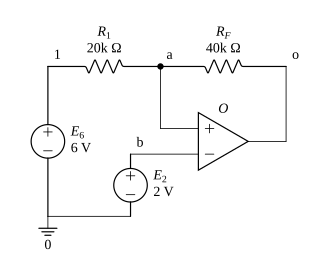

In [21]:
c9 = '''
e6,1,0,6
r1,1,a,20'k
e2,b,0,2
rf,a,o,40'k
o,a,b,o
'''
draw(c9)

In [22]:
r9 = dc(c9)
r9

Result(domain='dc')
  i_e2 = 0
  i_e6 = -1/5000
  i_o = -1/5000
  i_r1 = 1/5000
  i_rf = 1/5000
  p_e2 = 0
  p_e6 = -3/2500
  p_o = -3/2500
  p_r1 = 1/1250
  p_rf = 1/625
  r_e2 = oo
  r_e6 = 30000
  v_1 = 6
  v_a = 2
  v_b = 2
  v_e2 = 2
  v_e6 = 6
  v_o = -6
  v_r1 = 4
  v_rf = 8

## 10. TR5's Example 4-14 (Inverting, in full)

Find the input-output relationship, vo/vs, the formal way: the whole circuit with a symbolic load rl.

![The circuit of TR5's Example 4-14 (Inverting, in full)](https://learn.symbulator.com/assets/practice/tr5s-example-4-14-inverting-10.jpg)

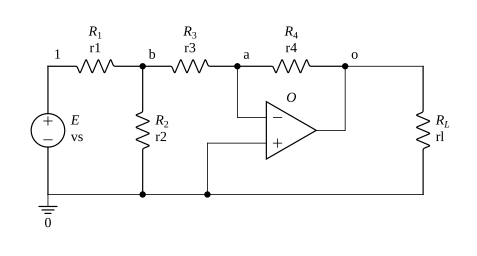

In [23]:
c10 = '''
e,1,0,vs
r1,1,b,r1
r2,b,0,r2
r3,b,a,r3
r4,a,o,r4
o,0,a,o
rl,o,0,rl
'''
draw(c10)

In [24]:
r10 = dc(c10)
r10

Result(domain='dc')
  i_e = vs*(-r2 - r3)/(r1*r2 + r1*r3 + r2*r3)
  i_o = r2*vs*(-r4 - rl)/(rl*(r1*r2 + r1*r3 + r2*r3))
  i_r1 = vs*(r2 + r3)/(r1*r2 + r1*r3 + r2*r3)
  i_r2 = r3*vs/(r1*r2 + r1*r3 + r2*r3)
  i_r3 = r2*vs/(r1*r2 + r1*r3 + r2*r3)
  i_r4 = r2*vs/(r1*r2 + r1*r3 + r2*r3)
  i_rl = -r2*r4*vs/(rl*(r1*r2 + r1*r3 + r2*r3))
  p_e = vs**2*(-r2 - r3)/(r1*r2 + r1*r3 + r2*r3)
  p_o = -r2**2*r4*vs**2*(r4 + rl)/(rl*(r1*r2 + r1*r3 + r2*r3)**2)
  p_r1 = r1*vs**2*(r2 + r3)**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_r2 = r2*r3**2*vs**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_r3 = r2**2*r3*vs**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_r4 = r2**2*r4*vs**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_rl = r2**2*r4**2*vs**2/(rl*(r1*r2 + r1*r3 + r2*r3)**2)
  r_e = (r1*r2 + r1*r3 + r2*r3)/(r2 + r3)
  v_1 = vs
  v_a = 0
  v_b = r2*r3*vs/(r1*r2 + r1*r3 + r2*r3)
  v_e = vs
  v_o = -r2*r4*vs/(r1*r2 + r1*r3 + r2*r3)
  v_r1 = r1*vs*(r2 + r3)/(r1*r2 + r1*r3 + r2*r3)
  v_r2 = r2*r3*vs/(r1*r2 + r1*r3 + r2*r3)
  v_r3 = r2*r3*vs/(r1*r2 + r1*r3 + r

In [25]:
evaluate(r10, 'vo/vs')

-r2*r4/(r1*r2 + r1*r3 + r2*r3)

## 11. TR5's Example 4-14 (Inverting, the quicker way)

The same ratio the quicker way: with the source at 1 and the load at 1, vo/v1 is the same expression, found faster.

![The circuit of TR5's Example 4-14 (Inverting, the quicker way)](https://learn.symbulator.com/assets/practice/tr5s-example-4-14-inverting-10.jpg)

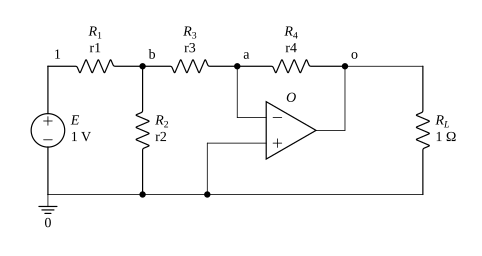

In [26]:
c11 = '''
e,1,0,1
r1,1,b,r1
r2,b,0,r2
r3,b,a,r3
r4,a,o,r4
o,0,a,o
rl,o,0,1
'''
draw(c11)

In [27]:
r11 = dc(c11)
r11

Result(domain='dc')
  i_e = (-r2 - r3)/(r1*r2 + r1*r3 + r2*r3)
  i_o = r2*(-r4 - 1)/(r1*r2 + r1*r3 + r2*r3)
  i_r1 = (r2 + r3)/(r1*r2 + r1*r3 + r2*r3)
  i_r2 = r3/(r1*r2 + r1*r3 + r2*r3)
  i_r3 = r2/(r1*r2 + r1*r3 + r2*r3)
  i_r4 = r2/(r1*r2 + r1*r3 + r2*r3)
  i_rl = -r2*r4/(r1*r2 + r1*r3 + r2*r3)
  p_e = (-r2 - r3)/(r1*r2 + r1*r3 + r2*r3)
  p_o = -r2**2*r4*(r4 + 1)/(r1*r2 + r1*r3 + r2*r3)**2
  p_r1 = r1*(r2 + r3)**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_r2 = r2*r3**2/(r1*r2 + r1*r3 + r2*r3)**2
  p_r3 = r2**2*r3/(r1*r2 + r1*r3 + r2*r3)**2
  p_r4 = r2**2*r4/(r1*r2 + r1*r3 + r2*r3)**2
  p_rl = r2**2*r4**2/(r1*r2 + r1*r3 + r2*r3)**2
  r_e = (r1*r2 + r1*r3 + r2*r3)/(r2 + r3)
  v_1 = 1
  v_a = 0
  v_b = r2*r3/(r1*r2 + r1*r3 + r2*r3)
  v_e = 1
  v_o = -r2*r4/(r1*r2 + r1*r3 + r2*r3)
  v_r1 = r1*(r2 + r3)/(r1*r2 + r1*r3 + r2*r3)
  v_r2 = r2*r3/(r1*r2 + r1*r3 + r2*r3)
  v_r3 = r2*r3/(r1*r2 + r1*r3 + r2*r3)
  v_r4 = r2*r4/(r1*r2 + r1*r3 + r2*r3)
  v_rl = -r2*r4/(r1*r2 + r1*r3 + r2*r3)

In [28]:
evaluate(r11, 'vo/v1')

-r2*r4/(r1*r2 + r1*r3 + r2*r3)

## 12. AS2's Practice Problem 5.4a (Transresistance)

A current-to-voltage converter, also called a transresistance amplifier: find vo/is, which comes back -r. The chapter says to evaluate vo/is; the source is called is1 here, since `is` is a Python keyword.

![The circuit of AS2's Practice Problem 5.4a (Transresistance)](https://learn.symbulator.com/assets/practice/as2s-practice-problem-5-4a-transresistance-13.jpg)

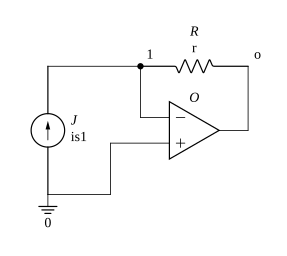

In [29]:
c12 = '''
j,0,1,is1
r,1,o,r
o,0,1,o
'''
draw(c12)

In [30]:
r12 = dc(c12)
r12

Result(domain='dc')
  i_j = is1
  i_o = -is1
  i_r = is1
  p_j = 0
  p_o = -is1**2*r
  p_r = is1**2*r
  r_j = 0
  v_1 = 0
  v_j = 0
  v_o = -is1*r
  v_r = is1*r

In [31]:
evaluate(r12, 'vo/is1')

-r

## 13. AS2's Practice Problem 5.4b (Transresistance)

Another transresistance amplifier: find vo/is1. The answer is the book's expression, gathered differently.

![The circuit of AS2's Practice Problem 5.4b (Transresistance)](https://learn.symbulator.com/assets/practice/as2s-practice-problem-5-4b-transresistance-14.jpg)

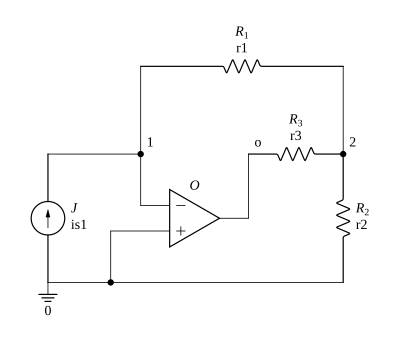

In [32]:
c13 = '''
j,0,1,is1
r1,1,2,r1
r2,2,0,r2
r3,2,o,r3
o,0,1,o
'''
draw(c13)

In [33]:
r13 = dc(c13)
r13

Result(domain='dc')
  i_j = is1
  i_o = is1*(-r1 - r2)/r2
  i_r1 = is1
  i_r2 = -is1*r1/r2
  i_r3 = is1*(r1 + r2)/r2
  p_j = 0
  p_o = -is1**2*(r1 + r2)*(r1*r2 + r1*r3 + r2*r3)/r2**2
  p_r1 = is1**2*r1
  p_r2 = is1**2*r1**2/r2
  p_r3 = is1**2*r3*(r1 + r2)**2/r2**2
  r_j = 0
  v_1 = 0
  v_2 = -is1*r1
  v_j = 0
  v_o = is1*(-r1*r2 - r1*r3 - r2*r3)/r2
  v_r1 = is1*r1
  v_r2 = -is1*r1
  v_r3 = is1*r3*(r1 + r2)/r2

In [34]:
evaluate(r13, 'vo/is1')

-r1 - r1*r3/r2 - r3

## 14. Bo2's Example 3.1 (Non-Inverting Amplifier)

The non-inverting amplifier: find the gain vo/v1 on the Evaluate line. It comes back 1 + r2/r1.

![The circuit of Bo2's Example 3.1 (Non-Inverting Amplifier)](https://learn.symbulator.com/assets/practice/bo2s-example-3-1-non-inverting-amplifier-16.jpg)

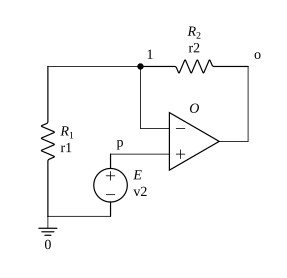

In [35]:
c14 = '''
e,p,0,v2
r1,1,0,r1
r2,1,o,r2
o,p,1,o
'''
draw(c14)

In [36]:
r14 = dc(c14)
r14

Result(domain='dc')
  i_e = 0
  i_o = v2/r1
  i_r1 = v2/r1
  i_r2 = -v2/r1
  p_e = 0
  p_o = v2**2*(-r1 - r2)/r1**2
  p_r1 = v2**2/r1
  p_r2 = r2*v2**2/r1**2
  r_e = oo
  v_1 = v2
  v_e = v2
  v_o = v2*(r1 + r2)/r1
  v_p = v2
  v_r1 = v2
  v_r2 = -r2*v2/r1

In [37]:
evaluate(r14, 'vo/v1')

(r1 + r2)/r1

## 15. AS2's Figure 5.16 (Non-Inverting Amplifier)

Find vo: ((r1+rf)/r1)*vi.

![The circuit of AS2's Figure 5.16 (Non-Inverting Amplifier)](https://learn.symbulator.com/assets/practice/as2s-figure-5-16-non-inverting-amplifier-17.jpg)

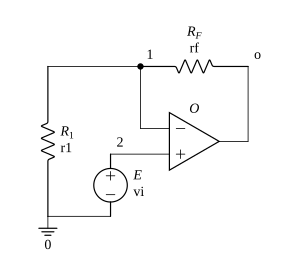

In [38]:
c15 = '''
e,2,0,vi
r1,0,1,r1
rf,1,o,rf
o,2,1,o
'''
draw(c15)

In [39]:
r15 = dc(c15)
r15

Result(domain='dc')
  i_e = 0
  i_o = vi/r1
  i_r1 = -vi/r1
  i_rf = -vi/r1
  p_e = 0
  p_o = vi**2*(-r1 - rf)/r1**2
  p_r1 = vi**2/r1
  p_rf = rf*vi**2/r1**2
  r_e = oo
  v_1 = vi
  v_2 = vi
  v_e = vi
  v_o = vi*(r1 + rf)/r1
  v_r1 = -vi
  v_rf = -rf*vi/r1

## 16. TR5's Example 4-13 (Non-Inverting, in one)

Find Vo/Vs in a single simulation: r2*(r3+r4)/((r1+r2)*r4).

![The circuit of TR5's Example 4-13 (Non-Inverting, in one)](https://learn.symbulator.com/assets/practice/tr5s-example-4-13-non-inverting-amplifier-18.jpg)

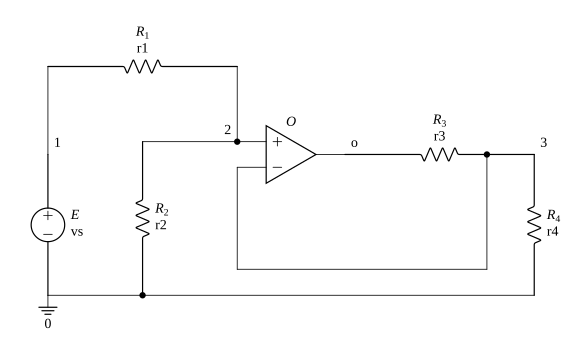

In [40]:
c16 = '''
e,1,0,vs
r1,1,2,r1
r2,2,0,r2
o,2,3,o
r3,o,3,r3
r4,3,0,r4
'''
draw(c16)

In [41]:
r16 = dc(c16)
r16

Result(domain='dc')
  i_e = -vs/(r1 + r2)
  i_o = r2*vs/(r4*(r1 + r2))
  i_r1 = vs/(r1 + r2)
  i_r2 = vs/(r1 + r2)
  i_r3 = r2*vs/(r4*(r1 + r2))
  i_r4 = r2*vs/(r4*(r1 + r2))
  p_e = -vs**2/(r1 + r2)
  p_o = r2**2*vs**2*(-r3 - r4)/(r4**2*(r1 + r2)**2)
  p_r1 = r1*vs**2/(r1 + r2)**2
  p_r2 = r2*vs**2/(r1 + r2)**2
  p_r3 = r2**2*r3*vs**2/(r4**2*(r1 + r2)**2)
  p_r4 = r2**2*vs**2/(r4*(r1 + r2)**2)
  r_e = r1 + r2
  v_1 = vs
  v_2 = r2*vs/(r1 + r2)
  v_3 = r2*vs/(r1 + r2)
  v_e = vs
  v_o = r2*vs*(r3 + r4)/(r4*(r1 + r2))
  v_r1 = r1*vs/(r1 + r2)
  v_r2 = r2*vs/(r1 + r2)
  v_r3 = r2*r3*vs/(r4*(r1 + r2))
  v_r4 = r2*vs/(r1 + r2)

In [42]:
evaluate(r16, 'vo/vs')

r2*(r3 + r4)/(r4*(r1 + r2))

## 17. TR5's Example 4-13 (the left half)

The same problem solved in stages: the left half's voltage divider gives v2/vs = r2/(r1+r2).

![The circuit of TR5's Example 4-13 (the left half)](https://learn.symbulator.com/assets/practice/tr5s-example-4-13-non-inverting-amplifier-18.jpg)

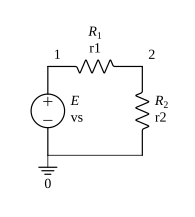

In [43]:
c17 = '''
e,1,0,vs
r1,1,2,r1
r2,2,0,r2
'''
draw(c17)

In [44]:
r17 = dc(c17)
r17

Result(domain='dc')
  i_e = -vs/(r1 + r2)
  i_r1 = vs/(r1 + r2)
  i_r2 = vs/(r1 + r2)
  p_e = -vs**2/(r1 + r2)
  p_r1 = r1*vs**2/(r1 + r2)**2
  p_r2 = r2*vs**2/(r1 + r2)**2
  r_e = r1 + r2
  v_1 = vs
  v_2 = r2*vs/(r1 + r2)
  v_e = vs
  v_r1 = r1*vs/(r1 + r2)
  v_r2 = r2*vs/(r1 + r2)

In [45]:
evaluate(r17, 'v2/vs')

r2/(r1 + r2)

## 18. TR5's Example 4-13 (the right half)

The right half gives vo/v2 = (r3+r4)/r4. The product of this and the previous entry is the whole circuit's gain.

![The circuit of TR5's Example 4-13 (the right half)](https://learn.symbulator.com/assets/practice/tr5s-example-4-13-non-inverting-amplifier-18.jpg)

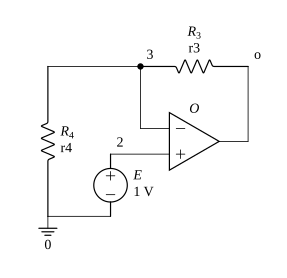

In [46]:
c18 = '''
e,2,0,1
o,2,3,o
r3,o,3,r3
r4,3,0,r4
'''
draw(c18)

In [47]:
r18 = dc(c18)
r18

Result(domain='dc')
  i_e = 0
  i_o = 1/r4
  i_r3 = 1/r4
  i_r4 = 1/r4
  p_e = 0
  p_o = (-r3 - r4)/r4**2
  p_r3 = r3/r4**2
  p_r4 = 1/r4
  r_e = oo
  v_2 = 1
  v_3 = 1
  v_e = 1
  v_o = (r3 + r4)/r4
  v_r3 = r3/r4
  v_r4 = 1

In [48]:
evaluate(r18, 'vo/v2')

(r3 + r4)/r4

## 19. AS2's Figure 5.17 (Voltage Follower)

The voltage follower: find vo, which is simply vi.

![The circuit of AS2's Figure 5.17 (Voltage Follower)](https://learn.symbulator.com/assets/practice/as2s-figure-5-17-voltage-follower-20.jpg)

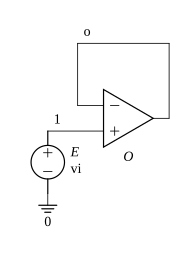

In [49]:
c19 = '''
e,1,0,vi
o,1,o,o
'''
draw(c19)

In [50]:
r19 = dc(c19)
r19

Result(domain='dc')
  i_e = 0
  i_o = 0
  p_e = 0
  p_o = 0
  r_e = oo
  v_1 = vi
  v_e = vi
  v_o = vi

## 20. TR5's Figure 4-32 (Voltage Follower, the source alone)

The bare source of circuit (b): find its maximum power and the power a 1 kohm load would draw. The load question comes ticked, and the Evaluate line reads prl at load = 1000, the chapter's prL|L=1000.

![The circuit of TR5's Figure 4-32 (Voltage Follower, the source alone)](https://learn.symbulator.com/assets/practice/tr5s-figure-4-32-voltage-follower-21.jpg)

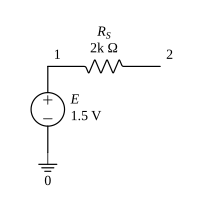

In [51]:
c20 = '''
e,1,0,1.5
rs,1,2,2'k
'''
draw(c20)

In [52]:
r20 = th(c20, '2', '0', domain='dc')
r20

TheveninResult(domain='dc', vth=1.50000000000000, ino=0.000750000000000000, req=2000.00000000000, pmax=0.000281250000000000)

In [53]:
evaluate(r20, 'prl', conditions=['load = 1000'])

0.000250000000000000

## 21. TR5's Figure 4-32 (Voltage Follower, buffered)

Circuit (a): the same source buffered by a voltage follower. Find prl, the power in the 1 kohm load: 2.25 mW. The load draws more than the bare source could deliver, because the ideal op amp in the schematic stands in for a real one with its own supply.

![The circuit of TR5's Figure 4-32 (Voltage Follower, buffered)](https://learn.symbulator.com/assets/practice/tr5s-figure-4-32-voltage-follower-21.jpg)

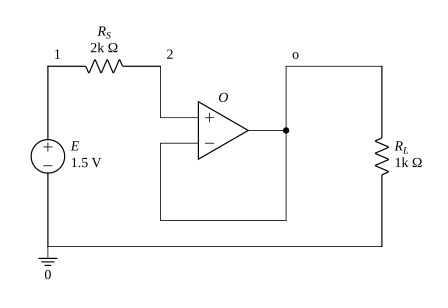

In [54]:
c21 = '''
e,1,0,1.5
rs,1,2,2'k
o,2,o,o
rl,o,0,1'k
'''
draw(c21)

In [55]:
r21 = dc(c21)
r21.rounded(3)

Result(domain='dc')
  i_e = 0
  i_o = 0.00150
  i_rl = 0.00150
  i_rs = 0
  p_e = 0
  p_o = -0.00225
  p_rl = 0.00225
  p_rs = 0
  r_e = oo
  v_1 = 1.50
  v_2 = 1.50
  v_e = 1.50
  v_o = 1.50
  v_rl = 1.50
  v_rs = 0

## 22. AS2's Example 5.5 (Inverting)

Find vo: -1 V.

![The circuit of AS2's Example 5.5 (Inverting)](https://learn.symbulator.com/assets/practice/as2s-example-5-5-inverting-23.jpg)

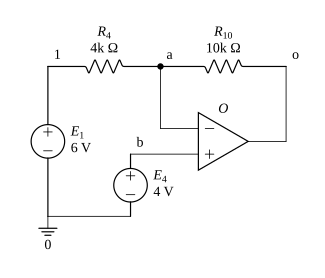

In [56]:
c22 = '''
e1,1,0,6
r4,1,a,4'k
r10,a,o,10'k
e4,b,0,4
o,b,a,o
'''
draw(c22)

In [57]:
r22 = dc(c22)
r22

Result(domain='dc')
  i_e1 = -1/2000
  i_e4 = 0
  i_o = -1/2000
  i_r10 = 1/2000
  i_r4 = 1/2000
  p_e1 = -3/1000
  p_e4 = 0
  p_o = -1/2000
  p_r10 = 1/400
  p_r4 = 1/1000
  r_e1 = 12000
  r_e4 = oo
  v_1 = 6
  v_a = 4
  v_b = 4
  v_e1 = 6
  v_e4 = 4
  v_o = -1
  v_r10 = 5
  v_r4 = 2

## 23. AS2's Practice Problem 5.5 (Non-Inverting)

Calculate vo: 7 V.

![The circuit of AS2's Practice Problem 5.5 (Non-Inverting)](https://learn.symbulator.com/assets/practice/as2s-practice-problem-5-5-non-inverting-24.jpg)

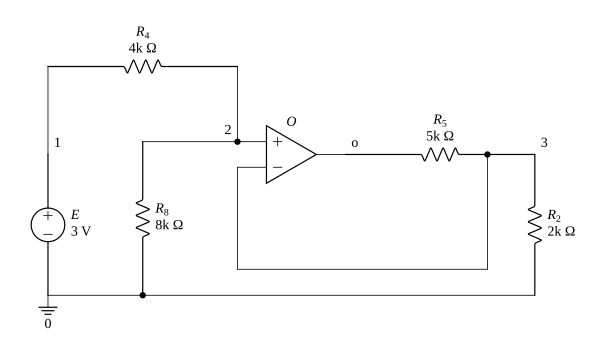

In [58]:
c23 = '''
e,1,0,3
r4,1,2,4'k
r8,2,0,8'k
r2,3,0,2'k
r5,3,o,5'k
o,2,3,o
'''
draw(c23)

In [59]:
r23 = dc(c23)
r23

Result(domain='dc')
  i_e = -1/4000
  i_o = 1/1000
  i_r2 = 1/1000
  i_r4 = 1/4000
  i_r5 = -1/1000
  i_r8 = 1/4000
  p_e = -3/4000
  p_o = -7/1000
  p_r2 = 1/500
  p_r4 = 1/4000
  p_r5 = 1/200
  p_r8 = 1/2000
  r_e = 12000
  v_1 = 3
  v_2 = 2
  v_3 = 2
  v_e = 3
  v_o = 7
  v_r2 = 2
  v_r4 = 1
  v_r5 = -5
  v_r8 = 2